In [1]:
import math

from common import *
from experiment import *
from data.http import HTTPExperiment
from treatments.picoquic import treatment_map

In [2]:
labels = [
    # 'picoquic',
    # 'picoquic_split',
    'picoquic_sidekick_0ms',
    'picoquic_sidekick_10ms',
    'picoquic_sidekick_20ms',
    'picoquic_sidekick_30ms',
    # 'picoquic_sidekick_60ms',
    # 'picoquic_sidekick_30ms_hint',
    # 'picoquic_sidekick_60ms_hint',
    'picoquic_iblt_0ms',
    'picoquic_iblt_10ms',
    'picoquic_iblt_20ms',
    'picoquic_iblt_30ms',
    # 'picoquic_iblt_60ms',
    # 'picoquic_iblt_30ms_hint',
    # 'picoquic_iblt_60ms_hint',
]

def TREATMENTS(labels=labels):
    return [treatment_map[label] for label in labels]

# def BBR_TREATMENTS(cca):
#     treatments = TREATMENTS()
#     for treatment in treatments:
#         treatment._label += f'_{cca}'
#         treatment._protocol_options += ['-cca', cca]
#     return treatments

LOSS1_VALUES = [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28]
def NETWORK_SETTINGS(loss_values=LOSS1_VALUES, n=len(LOSS1_VALUES)):
    return [
        NetworkSetting(bw1=20, bw2=20, delay1=1, delay2=100, loss1=loss1, loss2=0)
        for loss1 in loss_values[:n]
    ]

def DATA_SIZE(bottleneck_bw=20, time_s=10):
    return bottleneck_bw * 125000 * time_s

DATA_SIZES = [20*125000*10]

# Collect data for experiments

In [81]:
# NOTE: We have to run one trial at a time with the sidekick since it can only handle one connection at a time,
# and it decides which connection to handle by the first UDP packet it observes
max_networks = {
    'picoquic': 6,
    'picoquic_split': 20,
    'picoquic_iblt_0ms_freq10': 10,
    'picoquic_iblt_30ms_freq10': 20,
    'picoquic_iblt_30ms_hint_freq10': 20,
    'picoquic_iblt_60ms_hint_freq10': 20,
    'picoquic_iblt_30ms_hint_freq10_cache48000': 18,
    'picoquic_iblt_30ms_hint_freq10_cache48000_reset': 16,
    'picoquic_sidekick_0ms_freq10': 10,
    'picoquic_sidekick_30ms_freq10': 20,
    'picoquic_sidekick_60ms_freq10': 20,
    'picoquic_sidekick_30ms_hint_freq10': 20,
    'picoquic_iblt_30ms_hint_freq10_cache48000': 18,
    'picoquic_iblt_30ms_hint_freq10_cache48000_reset': 16,
    'picoquic_iblt_30ms_hint_freq10_cache16000': 10,
    'picoquic_iblt_30ms_hint_freq10_cache16000_reset': 8,
}

max_data_sizes = {
    'picoquic': 10000000,
}

def collect_loss_vs_metric_data(treatments, network_settings, data_size, n=10, max_networks=max_networks, execute=False):
    if execute:
        num_trials_range = range(1, n+1)
    else:
        num_trials_range = [n]
    for i in num_trials_range:
        exp = HTTPExperiment(num_trials=i, treatments=treatments, network_settings=network_settings, data_sizes=[data_size])
        raw_data = exp.to_raw_data(execute=execute, max_networks=max_networks)
    return raw_data

def collect_data_size_vs_throughput_data(treatments, network_setting, data_sizes, n=10, max_data_sizes=max_data_sizes, execute=False):
    if execute:
        num_trials_range = range(1, n+1)
    else:
        num_trials_range = [n]
    for i in num_trials_range:
        exp = HTTPExperiment(num_trials=i, treatments=treatments, network_settings=[network_setting], data_sizes=data_sizes)
        raw_data = exp.to_raw_data(execute=execute, max_data_sizes=max_data_sizes)
    return raw_data

I tried collecting metrics for various protocols, since the sniffer and proxy are both protocol-agnostic:
* **picoquic** seems to work as expected.
* **Cloudflare quiche** connections as of last year continue to timeout non-deterministically, which makes it annoying to evaluate. I'm pretty sure this is their bug.
* **Google quiche** at greater than 3% loss has a client error QUIC_TOO_MANY_RTOS. When a packet is sent over the network and no acknowledgement is received within a certain time frame, a retransmission timeout (RTO) occurs. This error essentially indicates that the network connection was too slow or unreliable to maintain a stable data stream, causing the connection to time out and fail. I think this is occurring because the QUIC server is retransmitting data frames in _new_ packets, but the client may be receiving the proxy-retransmitted _original_ packets and not properly acknowledging real retransmissions.
* **TCP** won't be recognized because the sniffers have been implemented to only look at UDP packets. However, this isn't fundamental and we could theoretically modify both to consider _all_ packets.

# Plot network metrics

## Plotting functions

In [44]:
def plot_loss_vs_metric_line(data, title, ylabel, ncol=3, ylim=0, delta=25, pdf=None):
    plt.figure(figsize=(6, 4))
    
    labels = data.treatments
    data_size = data.data_sizes[0]

    # Plot each label
    for label in labels:
        xs = []
        ys_raw = []

        for network in data.network_settings:
            if data_size not in data.data[label][network]:
                continue
            network_setting = data.exp.get_network_setting(network)
            xs.append(float(network_setting.settings['loss1']))
            ys_raw.append(data.data[label][network][data_size])

        ys = [y.p(50) for y in ys_raw]
        yerr_lower = [y.p(50) - y.p(50-delta) for y in ys_raw]
        yerr_upper = [y.p(50+delta) - y.p(50) for y in ys_raw]
        plt.errorbar(xs, ys, yerr=(yerr_lower, yerr_upper), marker='.', capsize=5, label=label)

    plt.title(title)
    plt.xlabel('Loss % near data receiver')
    plt.ylabel(ylabel)
    plt.grid()
    plt.xlim(0)
    plt.ylim(ylim)
    plot_title_and_legend(title, labels, base_height=1.13, row_height=0.07, title_height=0.08, ncol=ncol)
    if pdf:
        save_pdf(pdf)
    plt.show()

In [45]:
def plot_loss_vs_num_spurious(raw_data, pdf=None, ylim=0, ncol=3, sender=False, normalized=False):
    key = 'Sender' if sender else 'Receiver'
    def num_spurious_func(output):
        if 'additional_data' not in output:
            return 0
        data_key = f'num_spurious_{key.lower()}'
        if data_key not in output['additional_data']:
            print(output['additional_data'])
        num_spurious = output['additional_data'][data_key]
        if normalized:
            return num_spurious / output['time_s']
        else:
            return num_spurious

    plottable_data = raw_data.to_plottable_data(num_spurious_func)
    title = f'{data_size_str(plottable_data.data_sizes[0])} ({plottable_data.network_settings[0]})'
    ylabel = f'Num Spurious Retransmissions'
    if normalized:
        ylabel += ' / sec'
    plot_loss_vs_metric_line(plottable_data, ncol=ncol, title=title, ylim=ylim, ylabel=ylabel, pdf=pdf)

In [68]:
def plot_loss_vs_throughput(raw_data, title=None, ncol=2, pdf=None):
    plottable_data = raw_data.to_plottable_data('throughput_mbps')
    if not title:
        title = f'{data_size_str(plottable_data.data_sizes[0])} ({plottable_data.network_settings[0]})'
    ylabel = 'Goodput (Mbit/s)'
    plot_loss_vs_metric_line(plottable_data, title, ncol=ncol, ylabel=ylabel, pdf=pdf)

In [47]:
def plot_data_size_vs_throughput(data, network: str, ncol=2, delta=25, pdf=None):
    plt.figure(figsize=(6, 4))
    
    labels = data.treatments
    data_sizes = data.data_sizes

    # Plot each label
    for label in labels:
        xs = []
        ys_raw = []

        label_data = data.data[label][network]
        for data_size in data_sizes:
            if data_size not in label_data:
                continue
            xs.append(data_size)
            ys_raw.append(label_data[data_size])

        ys = [y.p(50) for y in ys_raw]
        yerr_lower = [y.p(50) - y.p(50-delta) for y in ys_raw]
        yerr_upper = [y.p(50+delta) - y.p(50) for y in ys_raw]
        plt.errorbar(xs, ys, yerr=(yerr_lower, yerr_upper), marker='.', capsize=5, label=label)

    plt.xlabel('Data Size (bytes)')
    plt.ylabel('Goodput (Mbit/s)')
    plt.grid()
    plt.xlim(0)
    plt.ylim((0, 20))
    plot_title_and_legend(network, labels, base_height=1.13, row_height=0.07, title_height=0.08, ncol=ncol)
    if pdf:
        save_pdf(pdf)
    plt.show()


## Loss vs. Throughput

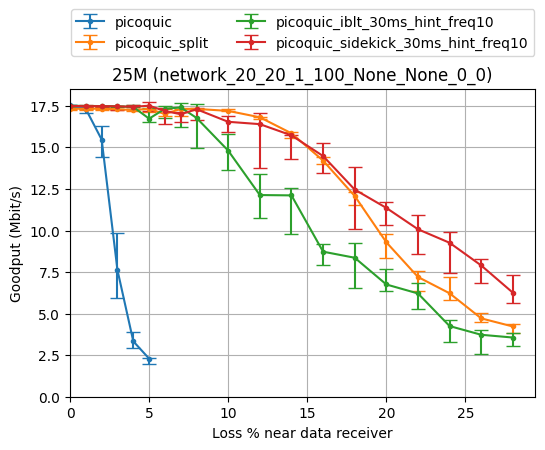

In [69]:
# 1. Improves throughput over the baseline + throughput fairness against split QUIC at high loss percentages?
loss_vs_throughput_data = collect_loss_vs_metric_data(
    n=10,
    execute=False,
    treatments=TREATMENTS([
        'picoquic',
        'picoquic_split',
        'picoquic_iblt_30ms_hint_freq10',
        'picoquic_sidekick_30ms_hint_freq10',
    ]),
    network_settings=NETWORK_SETTINGS(),
    data_size=DATA_SIZE(),
)
plot_loss_vs_throughput(loss_vs_throughput_data)#, pdf='../figures/http_benchmark.pdf')

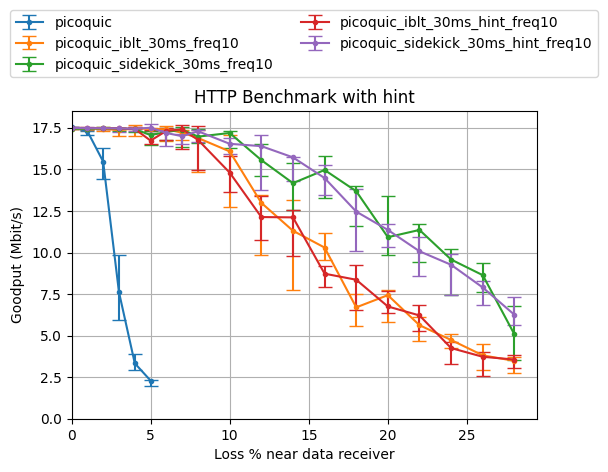

In [71]:
# 3. Sending with hint reduces tx_bytes (keeps perf).
http_data_hint = collect_loss_vs_metric_data(
    n=10, execute=False, network_settings=NETWORK_SETTINGS(), data_size=DATA_SIZE(),
    treatments=TREATMENTS([
        'picoquic',
        'picoquic_iblt_30ms_freq10',
        'picoquic_sidekick_30ms_freq10',
        'picoquic_iblt_30ms_hint_freq10',
        'picoquic_sidekick_30ms_hint_freq10',
    ]),
    
)
plot_loss_vs_throughput(http_data_hint, title='HTTP Benchmark with hint')

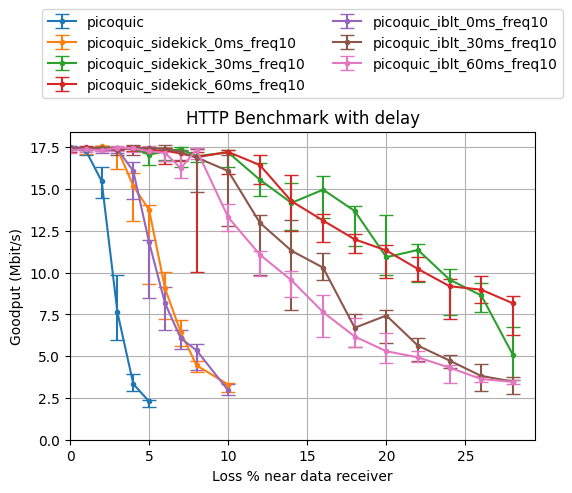

In [88]:
# 4. Sending with delay reduces spurious retx (keeps or improves perf.)
http_data_delay = collect_loss_vs_metric_data(
    n=10, execute=False, network_settings=NETWORK_SETTINGS(), data_size=DATA_SIZE(),
    treatments=TREATMENTS([
        'picoquic',
        'picoquic_sidekick_0ms_freq10',
        'picoquic_sidekick_30ms_freq10',
        'picoquic_sidekick_60ms_freq10',
        'picoquic_iblt_0ms_freq10',
        'picoquic_iblt_30ms_freq10',
        'picoquic_iblt_60ms_freq10',
    ]),
)
plot_loss_vs_throughput(http_data_delay, title='HTTP Benchmark with delay')

MISSING: sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 0 --loss2 0 -t 9 --label picoquic_iblt_30ms_hint_freq10_cache16000 --proxy sidekick --freq-ms 10 --freq-pkts 25 --threshold 100 --riblt --quack-hint --cache-capacity 16000 --network-statistics picoquic --client-quacker --ack-delay 30 -n 25000000
MISSING: sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 1 --loss2 0 -t 9 --label picoquic_iblt_30ms_hint_freq10_cache16000 --proxy sidekick --freq-ms 10 --freq-pkts 25 --threshold 100 --riblt --quack-hint --cache-capacity 16000 --network-statistics picoquic --client-quacker --ack-delay 30 -n 25000000
MISSING: sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 2 --loss2 0 -t 9 --label picoquic_iblt_30ms_hint_freq10_cache16000 --proxy sidekick --freq-ms 10 --freq-pkts 25 --threshold 100 --riblt --quack-hint --cache-capacity 16000 --network-statistics picoquic --client-quacker --ack-delay 30 -n 25000000
MISSING: sudo -E

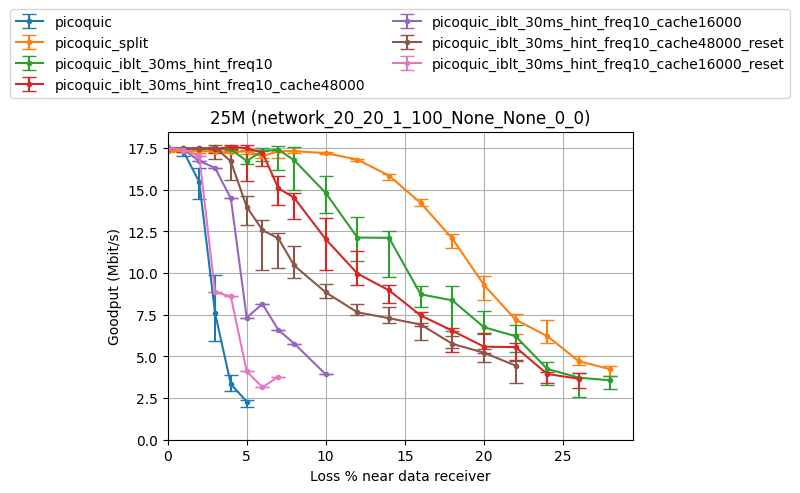

In [83]:
# 5. The cache policies keep the cache size low (keeps perf).
loss_vs_throughput_data = collect_loss_vs_metric_data(
    n=10,
    execute=False,
    treatments=TREATMENTS([
        'picoquic',
        'picoquic_split',
        'picoquic_iblt_30ms_hint_freq10',
        'picoquic_iblt_30ms_hint_freq10_cache48000',
        'picoquic_iblt_30ms_hint_freq10_cache16000',
        'picoquic_iblt_30ms_hint_freq10_cache48000_reset',
        'picoquic_iblt_30ms_hint_freq10_cache16000_reset',
    ]),
    network_settings=NETWORK_SETTINGS(),
    data_size=DATA_SIZE(),
)
plot_loss_vs_throughput(loss_vs_throughput_data)#, pdf='../figures/http_benchmark.pdf')
# plot_loss_vs_throughput('bbr1', bbr1_raw_data)
# plot_loss_vs_throughput('bbr3', bbr3_raw_data)
# plot_loss_vs_throughput('tcp', tcp_raw_data)
# plot_loss_vs_throughput('chromium', chromium_raw_data)

## Data Size vs. Throughput

In [51]:
data_sizes = [
    1000, 10000,
    100000, 200000, 500000,
    1000000, 2000000, 3000000, 4000000, 5000000, 6000000, 8000000,
    10000000, 12000000, 14000000, 16000000, 18000000,
    20000000, 24000000, 28000000, 32000000, 36000000,
    # 40000000, 50000000, 60000000, 70000000,
]

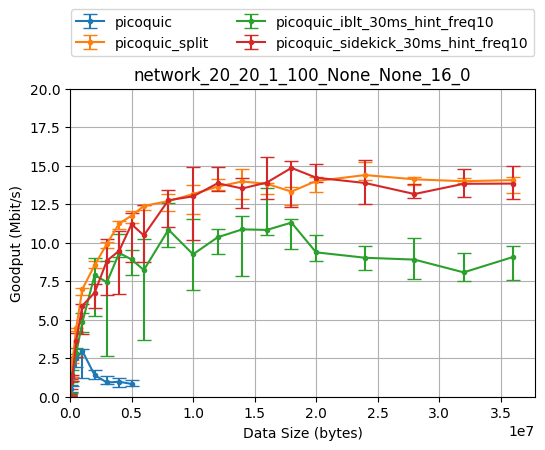

In [94]:
network_setting = NETWORK_SETTINGS(loss_values=[16], n=1)[0]
raw_data = collect_data_size_vs_throughput_data(
    n=10,
    execute=False,
    treatments=TREATMENTS([
        'picoquic',
        'picoquic_split',
        'picoquic_iblt_30ms_hint_freq10',
        'picoquic_sidekick_30ms_hint_freq10',
    ]),
    network_setting=network_setting,
    data_sizes=data_sizes,
    max_data_sizes={
        'picoquic': 10,
        'picoquic_split': 22,
        'picoquic_iblt_30ms_hint_freq10': 22,
        'picoquic_sidekick_30ms_hint_freq10': 22,
    },
)
data_size_vs_throughput_data = raw_data.to_plottable_data('throughput_mbps')
plot_data_size_vs_throughput(data_size_vs_throughput_data, network_setting.label())

In [63]:
# network_setting = NETWORK_SETTINGS(loss_values=[5], n=1)[0]
# raw_data = collect_data_size_vs_throughput_data(
#     n=10,
#     execute=False,
#     treatments=TREATMENTS([
#         'picoquic',
#         'picoquic_split',
#         'picoquic_iblt_0ms',
#         # 'picoquic_iblt_10ms',
#         # 'picoquic_iblt_20ms',
#         'picoquic_iblt_30ms',
#         'picoquic_iblt_30ms_hint',
#         # 'picoquic_iblt_60ms',
#     ]),
#     network_setting=network_setting,
#     data_sizes=data_sizes,
#     max_data_sizes={
#         'picoquic': 12,
#         'picoquic_split': 22,
#         'picoquic_iblt_0ms': 22,
#         'picoquic_iblt_30ms': 22,
#         'picoquic_iblt_30ms_hint': 22,
#         'picoquic_iblt_60ms': 22,
#     },
# )
# data_size_vs_throughput_data = raw_data.to_plottable_data('throughput_mbps')
# plot_data_size_vs_throughput(data_size_vs_throughput_data, network_setting.label())

In [64]:
# data_sizes = [
#     1000, 10000,
#     100000, 200000, 500000,
#     1000000, 2000000, 3000000, 4000000, 5000000, 6000000, 8000000,
#     10000000, 12000000, 14000000, 16000000, 18000000,
#     20000000, 24000000, 28000000, 32000000, 36000000, 40000000,
#     50000000, 60000000, 70000000,
# ]
# network_setting = NETWORK_SETTINGS(loss_values=[16], n=1)[0]
# raw_data = collect_data_size_vs_throughput_data(
#     n=10,
#     execute=False,
#     treatments=TREATMENTS([
#         'picoquic',
#         'picoquic_split',
#         'picoquic_iblt_0ms',
#         # 'picoquic_iblt_10ms',
#         # 'picoquic_iblt_20ms',
#         'picoquic_iblt_30ms',
#         'picoquic_iblt_30ms_hint',
#         'picoquic_iblt_60ms',
#     ]),
#     network_setting=network_setting,
#     data_sizes=data_sizes,
#     max_data_sizes={
#         'picoquic': 10,
#         'picoquic_split': 22,
#         'picoquic_iblt_0ms': 10,
#         'picoquic_iblt_10ms': 16,
#         'picoquic_iblt_20ms': 22,
#         'picoquic_iblt_30ms': 22,
#         'picoquic_iblt_30ms_hint': 22,
#         'picoquic_iblt_60ms': 22,
#     },
# )
# data_size_vs_throughput_data = raw_data.to_plottable_data('throughput_mbps')
# plot_data_size_vs_throughput(data_size_vs_throughput_data, network_setting.label())

## Num Spurious

MISSING: sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 22 --loss2 0 -t 9 --label picoquic_iblt_30ms --proxy sidekick --freq-ms 25 --freq-pkts 8 --threshold 80 --riblt --network-statistics picoquic --client-quacker --ack-delay 30 -n 25000000
MISSING: sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 24 --loss2 0 -t 9 --label picoquic_iblt_30ms --proxy sidekick --freq-ms 25 --freq-pkts 8 --threshold 80 --riblt --network-statistics picoquic --client-quacker --ack-delay 30 -n 25000000
MISSING: sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 26 --loss2 0 -t 9 --label picoquic_iblt_30ms --proxy sidekick --freq-ms 25 --freq-pkts 8 --threshold 80 --riblt --network-statistics picoquic --client-quacker --ack-delay 30 -n 25000000
MISSING: sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 28 --loss2 0 -t 9 --label picoquic_iblt_30ms --proxy sidekick --freq-ms 25 --freq-pkts 8 --threshold 80 --riblt --

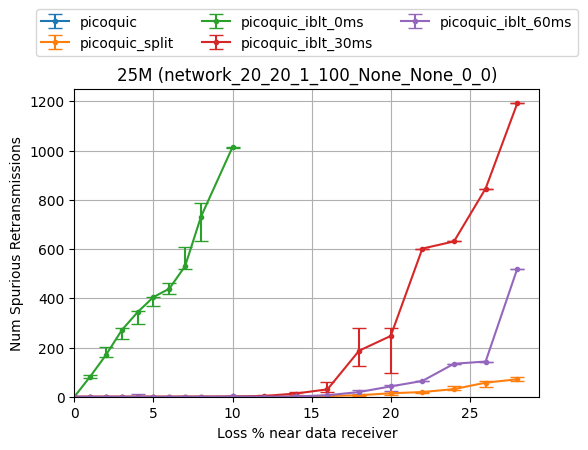

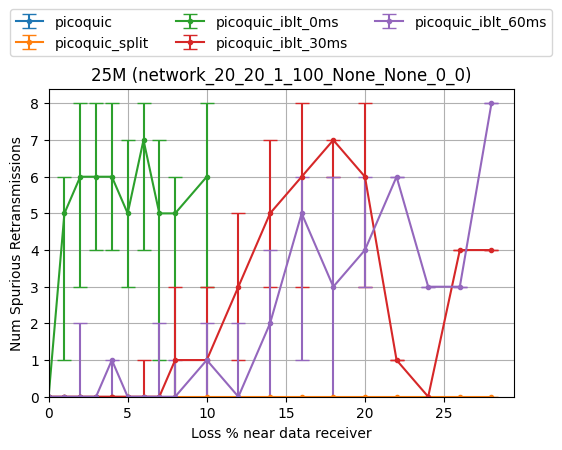

In [15]:
loss_vs_num_spurious_data = collect_loss_vs_metric_data(
    n=10,
    execute=False,
    treatments=TREATMENTS([
        'picoquic',
        'picoquic_split',
        'picoquic_iblt_0ms',
        # 'picoquic_iblt_10ms',
        # 'picoquic_iblt_20ms',
        'picoquic_iblt_30ms',
        'picoquic_iblt_60ms',
    ]),
    max_networks={
        'picoquic': 6,
        'picoquic_iblt_0ms': 10,
        'picoquic_iblt_10ms': 12,
        'picoquic_iblt_20ms': 12,
        'picoquic_iblt_30ms': 20,
        'picoquic_iblt_60ms': 20,
        'picoquic_split': 20,
    },
    network_settings=NETWORK_SETTINGS(),
    data_size=DATA_SIZE(),
)

ylim = 0
plot_loss_vs_num_spurious(loss_vs_num_spurious_data, ylim=ylim, sender=False, normalized=False)
plot_loss_vs_num_spurious(loss_vs_num_spurious_data, ylim=ylim, sender=True, normalized=False)
# plot_loss_vs_num_spurious(loss_vs_num_spurious_data, ylim=ylim, normalized=True)

MISSING: sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 22 --loss2 0 -t 2 --label picoquic_sidekick_30ms --proxy sidekick --freq-ms 25 --freq-pkts 8 --threshold 20 --network-statistics picoquic --client-quacker --ack-delay 30 -n 25000000
MISSING: sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 24 --loss2 0 -t 2 --label picoquic_sidekick_30ms --proxy sidekick --freq-ms 25 --freq-pkts 8 --threshold 20 --network-statistics picoquic --client-quacker --ack-delay 30 -n 25000000
MISSING: sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 26 --loss2 0 -t 2 --label picoquic_sidekick_30ms --proxy sidekick --freq-ms 25 --freq-pkts 8 --threshold 20 --network-statistics picoquic --client-quacker --ack-delay 30 -n 25000000
MISSING: sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 28 --loss2 0 -t 2 --label picoquic_sidekick_30ms --proxy sidekick --freq-ms 25 --freq-pkts 8 --threshold 20 --network-statisti

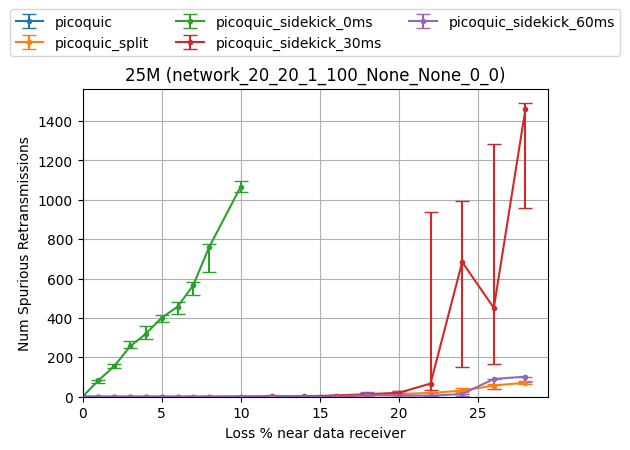

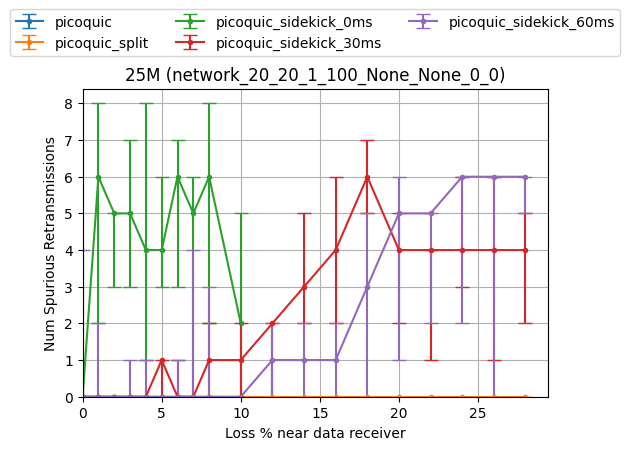

In [16]:
loss_vs_num_spurious_data = collect_loss_vs_metric_data(
    n=10,
    execute=False,
    treatments=TREATMENTS([
        'picoquic',
        'picoquic_split',
        'picoquic_sidekick_0ms',
        # 'picoquic_sidekick_10ms',
        # 'picoquic_sidekick_20ms',
        'picoquic_sidekick_30ms',
        'picoquic_sidekick_60ms',
        # 'picoquic_sidekick_60ms_hint',
    ]),
    network_settings=NETWORK_SETTINGS(),
    data_size=DATA_SIZE(),
)
ylim = 0
plot_loss_vs_num_spurious(loss_vs_num_spurious_data, ylim=ylim, sender=False, normalized=False)
plot_loss_vs_num_spurious(loss_vs_num_spurious_data, ylim=ylim, sender=True, normalized=False)
# plot_loss_vs_num_spurious(loss_vs_num_spurious_data, ylim=ylim, normalized=True)

## Other Network Metrics

In [10]:
def plot_loss_vs_network_metric(prefix, raw_data, metric):
    def metric_func(iface, metric):
        def func(output):
            statistics = output['statistics']
            iface_index = statistics['ifaces'].index(iface)
            return statistics[metric][iface_index]
        return func

    for iface in ['h1-eth0', 'p1-eth1', 'h2-eth0', 'p1-eth0']:
        title = f'{prefix} {data_size_str(DATA_SIZES()[0])} ({NETWORK_SETTINGS()[0].label()})'
        ylabel = f'{iface} {metric}'
        plottable_data = PlottableData(raw_data, metric_func(iface, metric))
        plot_loss_vs_metric_line(plottable_data, title=title, ylabel=ylabel)

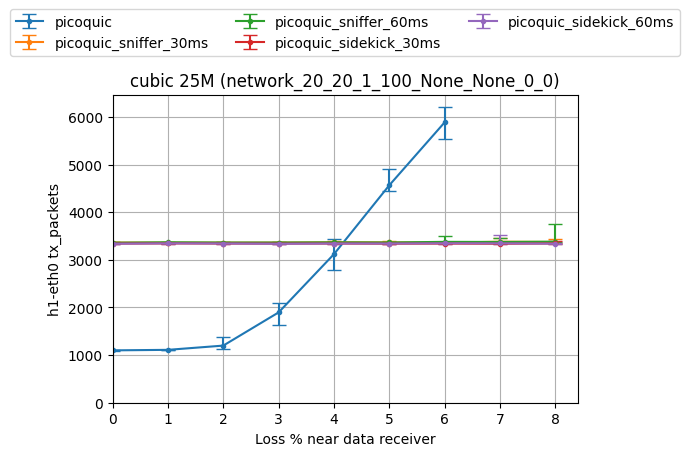

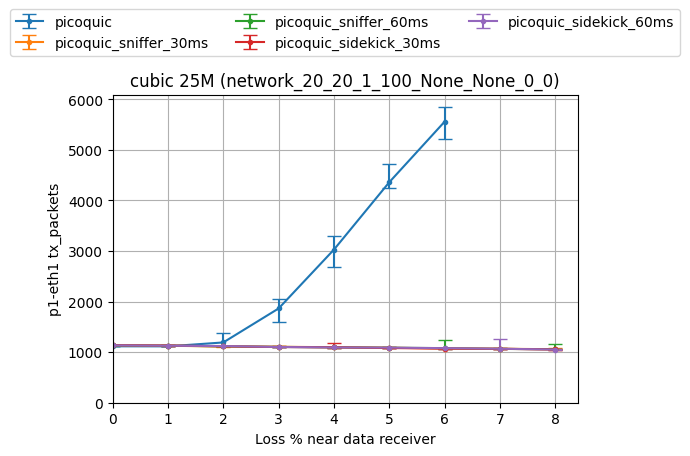

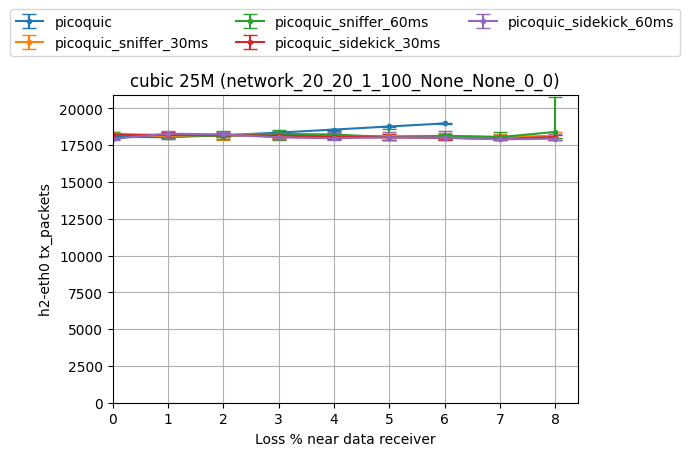

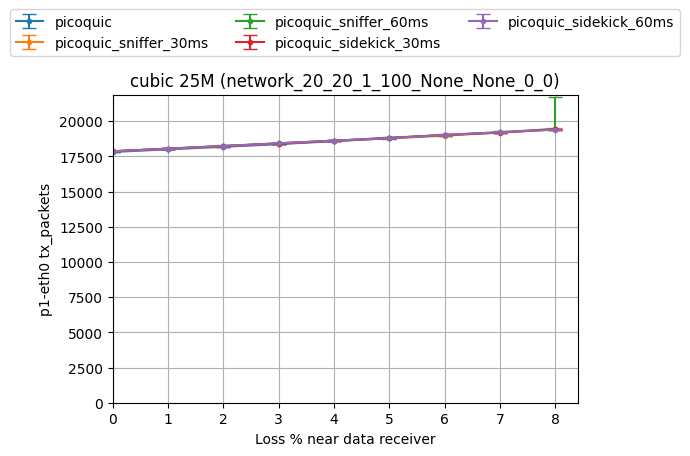

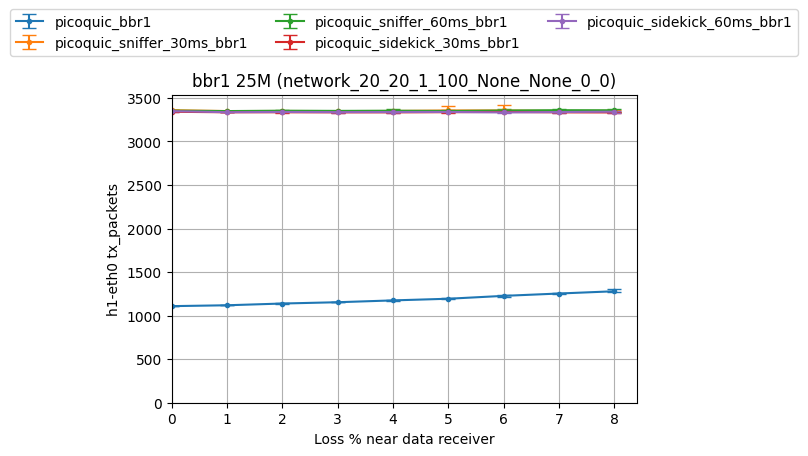

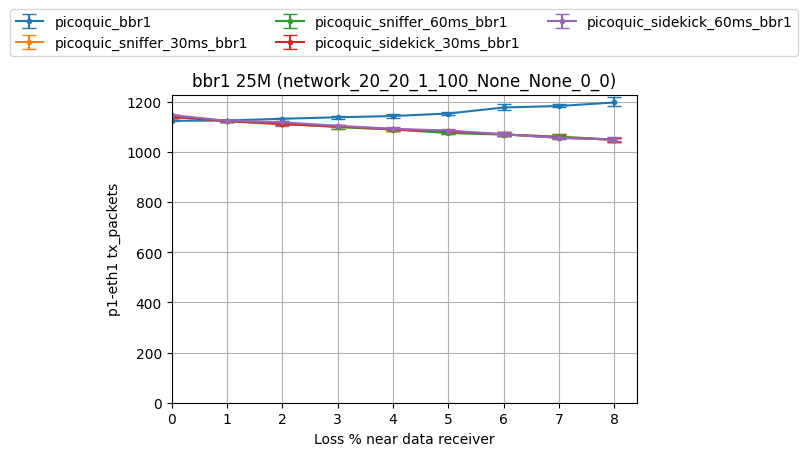

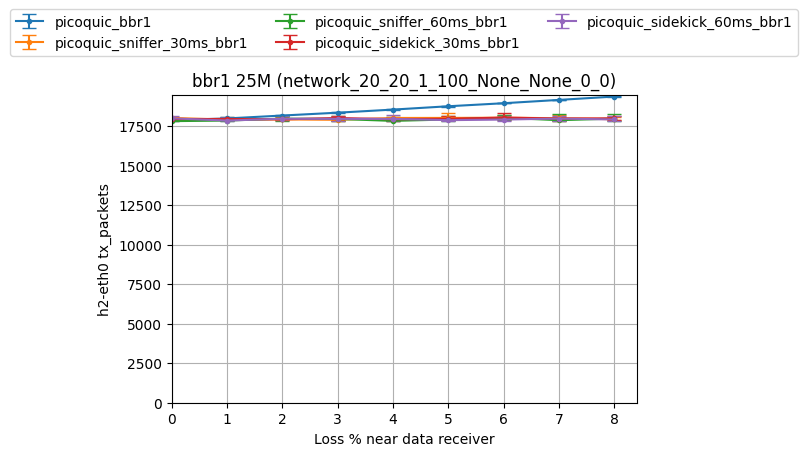

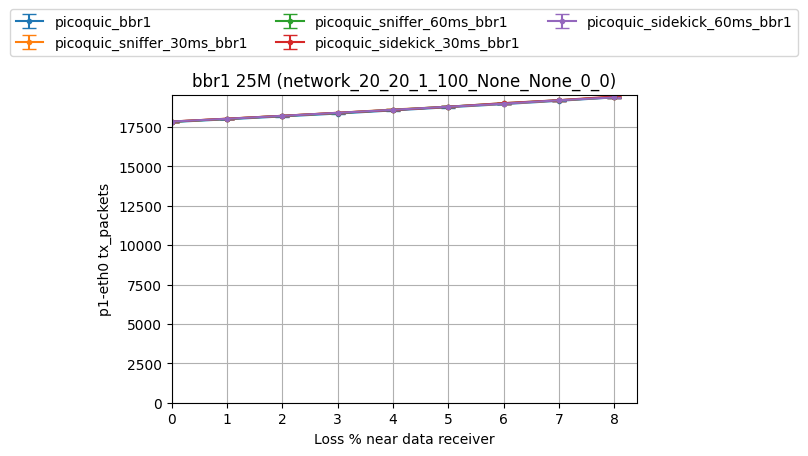

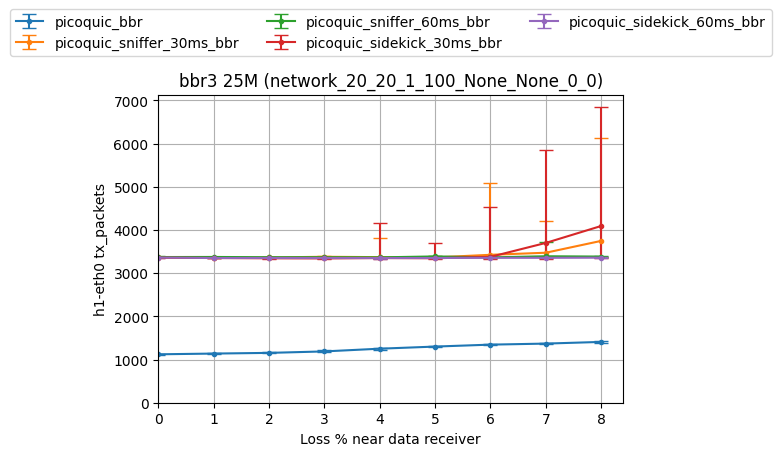

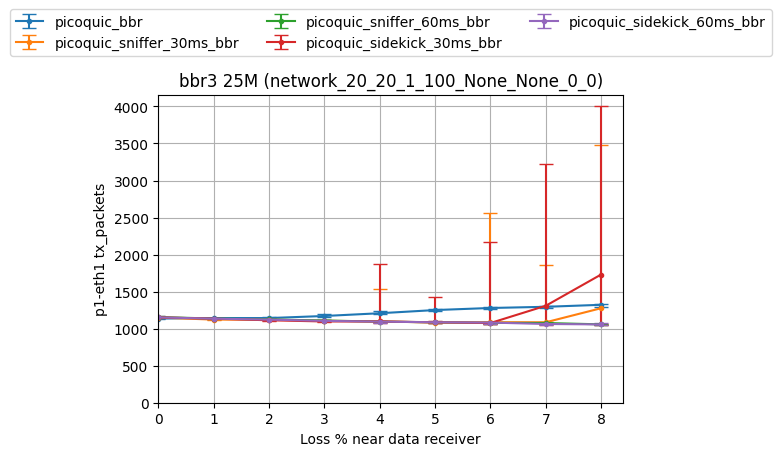

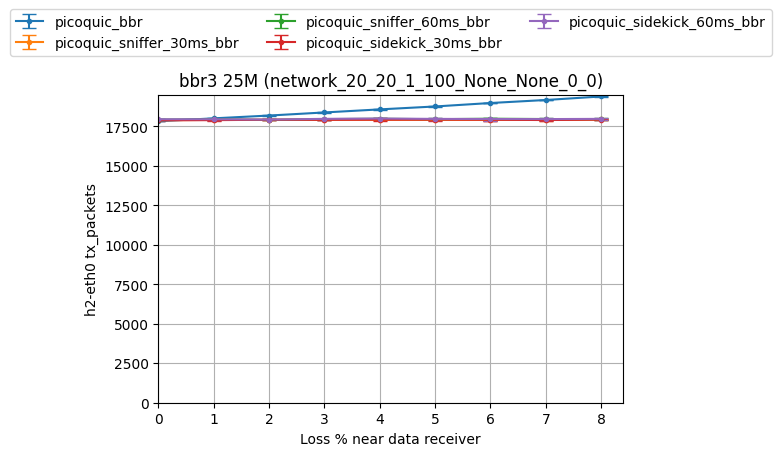

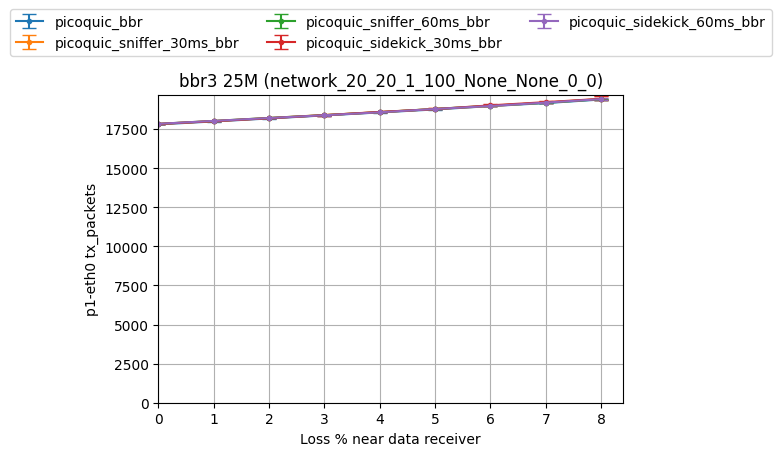

In [11]:
plot_loss_vs_network_metric('cubic', picoquic_raw_data, 'tx_packets')
plot_loss_vs_network_metric('bbr1', bbr1_raw_data, 'tx_packets')
plot_loss_vs_network_metric('bbr3', bbr3_raw_data, 'tx_packets')